# C05 — Image-Space Parallel Imaging (SENSE)
### Module 4 · Day 24 · *Computational MRI, Lecture 5*

**Goal:** acquire less k-space, then *recover* the missing data from the redundancy of a
multi-coil receive array. By the end of this notebook you will:

- combine multi-coil images (sum-of-squares, matched-filter, with/without noise covariance);
- reconstruct regularly-undersampled Cartesian data with **SENSE**;
- compute the **g-factor** and measure the SNR cost of acceleration.

This notebook is **self-contained**: it builds a realistic synthetic 8-coil brain phantom so
everything runs without any download. If you have the course file `data_brain_8coils.mat`,
drop it next to this notebook and it will be used automatically.

> Sections 0–5 are the *tutorial*. Then come the **Lab 5 exercises** (with skeletons to fill in)
> followed by **worked solutions**. Try the exercises before scrolling to the solutions.

## 0 · Setup

Two FFT helpers used internally by the reconstruction engine. We deliberately use **corner-DC**
transforms (no `fftshift`) so the aliasing bookkeeping is exact and easy to reason about:
undersampling `k[::R]` folds image rows that are exactly `N/R` apart.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

%matplotlib inline
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

# Corner-DC 2D transforms (no fftshift) -- used by the recon engine.
def fft2c(x):  return np.fft.fft2(x,  axes=(0, 1))
def ifft2c(x): return np.fft.ifft2(x, axes=(0, 1))

def show(imgs, titles, cmap='gray', cols=None, size=3, vmax=None):
    imgs = imgs if isinstance(imgs, (list, tuple)) else [imgs]
    titles = titles if isinstance(titles, (list, tuple)) else [titles]
    cols = cols or len(imgs)
    rows = int(np.ceil(len(imgs) / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(size*cols, size*rows))
    ax = np.atleast_1d(ax).ravel()
    for a, im, t in zip(ax, imgs, titles):
        a.imshow(np.abs(im), cmap=cmap, vmax=vmax); a.set_title(t, fontsize=10); a.axis('off')
    for a in ax[len(imgs):]: a.axis('off')
    plt.tight_layout(); plt.show()


### 0.1 · Build (or load) the data

We need three things, matching the layout of the course file `data_brain_8coils.mat`:

| symbol | shape | meaning |
|---|---|---|
| `d` | `(N, N, Nc)` | fully-sampled k-space, dims `[PE, FE, channels]` |
| `c` | `(N, N, Nc)` | complex coil sensitivity maps |
| `n` | `(N, Nc)`    | noise-only scan (RF off), for the covariance $\boldsymbol\Psi$ |

The phase-encode (PE) direction is **rows / axis 0** (anterior–posterior), as the lab specifies.
We use `N = 252` so that `N` is divisible by 2, 3 and 4 (clean folding for every R).

In [2]:
Nc = 8
USE_MAT = False
try:
    from scipy.io import loadmat
    mat = loadmat('data_brain_8coils.mat')
    d, c, n = mat['d'], mat['c'], mat['n']
    N = d.shape[0]; USE_MAT = True
    print('Loaded data_brain_8coils.mat', d.shape)
except Exception as e:
    print('No .mat found -> generating synthetic 8-coil phantom.')

if not USE_MAT:
    from skimage.data import shepp_logan_phantom
    from skimage.transform import resize
    N = 252

    # --- ground-truth image (Shepp-Logan brain phantom), centered in the array ---
    phantom = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True).astype(np.complex128)

    # --- 8 complex coil sensitivities on a ring around the FOV ---
    yy, xx = np.mgrid[0:N, 0:N]
    cy, cx = (N - 1)/2, (N - 1)/2
    c = np.zeros((N, N, Nc), dtype=np.complex128)
    ring = 0.50 * N
    for i in range(Nc):
        ang = 2*np.pi*i/Nc
        py, px = cy + ring*np.sin(ang), cx + ring*np.cos(ang)
        r2 = (yy - py)**2 + (xx - px)**2
        mag = np.exp(-r2 / (2*(0.24*N)**2))                 # localized -> distinct coils
        phase = np.pi * ((yy - py) + (xx - px)) / N         # smooth coil phase
        c[:, :, i] = mag * np.exp(1j*phase)
    c /= np.abs(c).max()                                    # peak ~1; background stays ~0

    # --- realistic, mildly-correlated coil noise covariance Psi ---
    rho = 0.30
    idx = np.arange(Nc)
    Psi_true = (rho ** np.abs(idx[:, None] - idx[None, :])).astype(np.complex128)
    Lnoise = np.linalg.cholesky(Psi_true)
    noise_level = 0.015
    def draw_noise(shape):
        w = (rng.normal(size=shape + (Nc,)) + 1j*rng.normal(size=shape + (Nc,))) / np.sqrt(2)
        return noise_level * (w @ Lnoise.T)

    # --- fully-sampled multi-coil k-space + a noise-only scan ---
    coil_images = c * phantom[:, :, None] + draw_noise((N, N))
    d = fft2c(coil_images)
    n = draw_noise((N,))                                    # (N, Nc) noise-only scan

print('d', d.shape, '| c', c.shape, '| n', n.shape)


No .mat found -> generating synthetic 8-coil phantom.


d (252, 252, 8) | c (252, 252, 8) | n (252, 8)


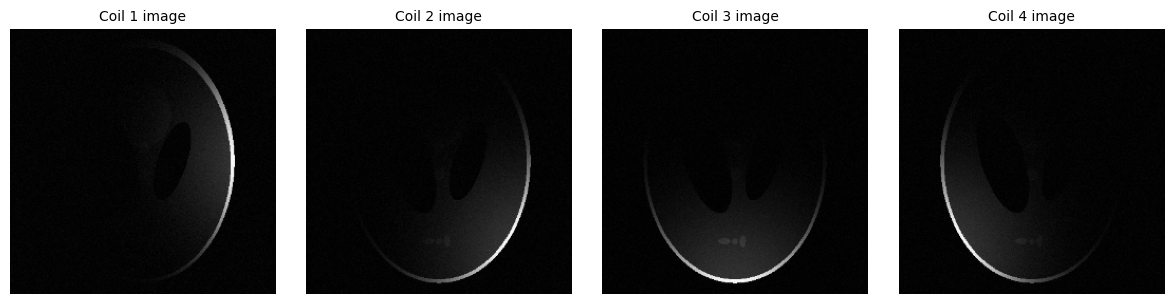

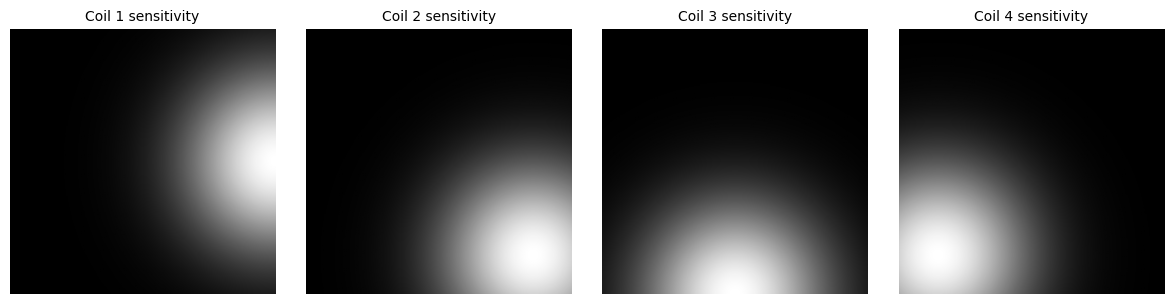

In [3]:
# Quick look at the array: 4 coil images and their sensitivity maps
coil_imgs = ifft2c(d)
show([coil_imgs[:, :, i] for i in range(4)],
     [f'Coil {i+1} image' for i in range(4)])
show([c[:, :, i] for i in range(4)],
     [f'Coil {i+1} sensitivity' for i in range(4)])


## 1 · Why we undersample, and what goes wrong

The **triangle of fate** says we can optimise only two of {scan time, resolution, SNR}.
Going faster the brute-force way (stronger, faster-switching gradients) is blocked by hardware
power ($\propto R^3$), an SNR penalty ($\propto\sqrt R$) and peripheral nerve stimulation.

The alternative: **skip phase-encode lines**. Keeping every $R$-th line doubles $\Delta k_y$, which
*halves* the field of view ($\mathrm{FOV}=1/\Delta k_y$). Anything outside the reduced FOV wraps
around. Let's see the fold-over for $R=2$ on a single coil (plain inverse FFT, no PI yet).

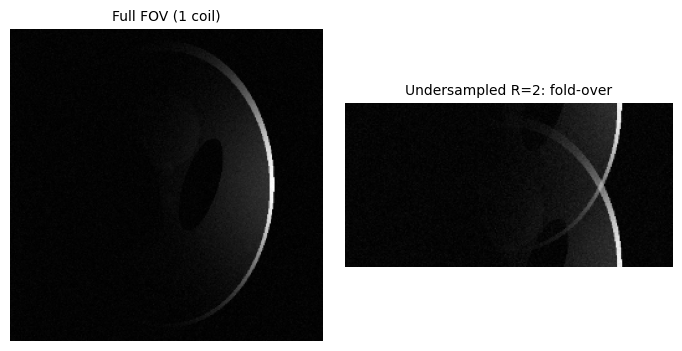

Each pixel in the aliased image is the sum of R = 2 true pixels spaced N/R = 126 rows apart.


In [4]:
R = 2
single = d[:, :, 0]                       # one coil's full k-space
under  = single[::R]                      # keep every R-th PE line  -> (N/R, N)
aliased_single = ifft2c(under)            # reduced-FOV image -> fold-over

show([ifft2c(single), aliased_single],
     ['Full FOV (1 coil)', f'Undersampled R={R}: fold-over'],
     size=3.5)
print('Each pixel in the aliased image is the sum of R =', R,
      'true pixels spaced N/R =', N // R, 'rows apart.')


## 2 · The sensitivity-encoding equation

Coil $i$ measures the true image $f$ weighted by its complex sensitivity $c_i$, plus noise:

$$ m_i(\mathbf r) = c_i(\mathbf r)\,f(\mathbf r) + n_i(\mathbf r). $$

Pixels near a coil are bright, pixels far away are dark — **the coils perform extra spatial
encoding for free.** That is the redundancy parallel imaging exploits.

## 3 · Combining coils (full sampling)

Before accelerating, the warm-up problem: turn $N_c$ coil images into one. Three estimators.

**Sum-of-squares (SoS)** — no sensitivities needed, ~10% SNR penalty:
$$ f = \sqrt{\textstyle\sum_i |m_i|^2}. $$

**Matched-filter / least-squares (Roemer 1990)** — uses sensitivities, per pixel $\mathbf C$ is $N_c\times1$:
$$ f = (\mathbf C^H\mathbf C)^{-1}\mathbf C^H\mathbf m. $$

**Noise-weighted** — coil noise is *correlated*; pre-whiten with the covariance $\boldsymbol\Psi$:
$$ f = (\mathbf C^H\boldsymbol\Psi^{-1}\mathbf C)^{-1}\mathbf C^H\boldsymbol\Psi^{-1}\mathbf m,
\qquad \hat{\boldsymbol\Psi}=\tfrac1{N_s}\,\mathbf n^H\mathbf n. $$

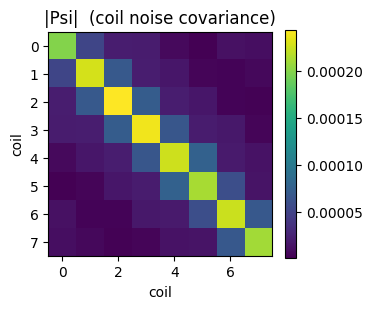

Off-diagonal correlation is visible -> noise is shared between neighbouring coils.


In [5]:
def estimate_psi(noise_scan):
    '''Coil noise covariance from a noise-only scan, shape (Ns, Nc) -> (Nc, Nc).'''
    Ns = noise_scan.shape[0]
    return (noise_scan.conj().T @ noise_scan) / Ns

Psi = estimate_psi(n)
plt.figure(figsize=(3.2, 3.2))
plt.imshow(np.abs(Psi), cmap='viridis'); plt.title('|Psi|  (coil noise covariance)')
plt.colorbar(fraction=0.046); plt.xlabel('coil'); plt.ylabel('coil'); plt.show()
print('Off-diagonal correlation is visible -> noise is shared between neighbouring coils.')


## 4 · SENSE: unfolding the aliasing

Accelerate by $R$. After the inverse FFT, each coil image has $R$ true pixels (spaced $N/R$ apart)
piled on top of each other. For one aliased location, collect the $N_c$ coil readings $\mathbf I$ and
the $N_c\times R$ matrix $\mathbf C$ of sensitivities at the $R$ folded positions:

$$
\begin{pmatrix} I_1\\ \vdots\\ I_{N_c}\end{pmatrix}
=
\begin{pmatrix} c_1(u_1) & \cdots & c_1(u_R)\\ \vdots & & \vdots\\ c_{N_c}(u_1)&\cdots&c_{N_c}(u_R)\end{pmatrix}
\begin{pmatrix} u_1\\ \vdots\\ u_R\end{pmatrix},
\qquad
\mathbf u = (\mathbf C^H\boldsymbol\Psi^{-1}\mathbf C)^{-1}\mathbf C^H\boldsymbol\Psi^{-1}\mathbf I.
$$

Solvable as long as $N_c \ge R$. Let's unfold **one** aliased pixel by hand to make it concrete.

In [6]:
R = 2
Nr = N // R
aliased = ifft2c(d[::R])                  # (Nr, N, Nc) folded coil images
yr, x = Nr // 2, N // 2                    # pick a central aliased location
pos = (yr + np.arange(R) * Nr) % N         # the R true rows that folded together
print('folded rows:', pos, ' (column', x, ')')

C = c[pos, x, :].T                         # Nc x R  (rows = coils, cols = folded pixels)
I = aliased[yr, x, :]                      # Nc      (the measured aliased coil readings)
Psi_inv = inv(Psi)
u = inv(C.conj().T @ Psi_inv @ C) @ (C.conj().T @ Psi_inv @ I)   # R unfolded values
print('unfolded |u| :', np.abs(u))
print('SoS reference:', np.sqrt(np.sum(np.abs(coil_imgs[pos, x, :])**2, axis=1)))


folded rows: [ 63 189]  (column 126 )
unfolded |u| : [0.293 0.209]
SoS reference: [0.221 0.168]


## 5 · The g-factor — the price of acceleration

$$ \mathrm{SNR}_{\text{acc}} = \frac{\mathrm{SNR}_{\text{full}}}{g\sqrt R}. $$

The $\sqrt R$ is unavoidable (you collected $R\times$ less data). The **g-factor** $g\ge 1$ is *extra*
noise amplification from inverting an ill-conditioned $\mathbf C$. It is **local** and grows fast with $R$:

$$ g_\rho=\sqrt{\big[(\mathbf C^H\boldsymbol\Psi^{-1}\mathbf C)^{-1}\big]_{\rho\rho}\,
\big[\mathbf C^H\boldsymbol\Psi^{-1}\mathbf C\big]_{\rho\rho}}. $$

Reduce it with: more/better coils (hardware), regularization (software), or spreading the
acceleration over 2 dimensions in 3D imaging ($2\times2$ instead of $4\times1$).

That theory is exactly what you'll implement in the exercises. 👇

---
# 🏋️ Lab 5 — Exercises

> *Computational MR Imaging, Laboratory 5: Image-space parallel imaging.*
> Fill in the cells marked `# YOUR CODE HERE`. Worked solutions follow in the next section —
> resist peeking until you've tried.

**Before you start:** make sure you're comfortable with `numpy`/`scipy.linalg` `inv` and `pinv`,
the `.T` transpose, `.conj()`, and the `@` matrix-multiply operator.

### Exercise 1 — Multicoil combination

1. Implement **sum-of-squares** and **matched-filter (least-squares)** coil combination.
2. Combine the fully-sampled multicoil images **with** and **without** the noise covariance $\boldsymbol\Psi$.
3. Comment on the effect of using the noise correlation matrix.

In [7]:
# ---- Exercise 1: implement these two functions ----

def coil_combine_sos(coil_images):
    '''Root sum-of-squares over the coil axis (last axis). Returns (N, N) real image.'''
    # YOUR CODE HERE
    raise NotImplementedError

def coil_combine_matched(coil_images, sens, psi=None):
    '''Matched-filter / least-squares combination, per pixel:
         f = (C^H Psi^-1 C)^-1 C^H Psi^-1 m
       coil_images, sens: (N, N, Nc);  psi: (Nc, Nc) or None (=identity).
       Returns complex (N, N).'''
    # YOUR CODE HERE
    raise NotImplementedError

# Once implemented, run:
# imgs = ifft2c(d)
# sos      = coil_combine_sos(imgs)
# mf_noPsi = coil_combine_matched(imgs, c, psi=None)
# mf_Psi   = coil_combine_matched(imgs, c, psi=estimate_psi(n))
# show([sos, mf_noPsi, mf_Psi], ['Sum of squares', 'Matched filter (no Psi)', 'Matched filter (with Psi)'])


### Exercise 2 — Cartesian SENSE & g-factor

1. Write a **SENSE** function that unfolds undersampled multicoil data using the sensitivity maps.
2. Simulate acceleration `R = [2, 3, 4]` along the **phase-encode (row)** direction. For each R:
   - reconstruct with SENSE and compute the **average g-factor**;
   - report **PSNR** and **SSIM** against the matched-filter combination of the full data (the
     ground truth) — remember to normalise before comparing;
   - plot the reconstruction, the error map, and the g-factor map.

In [8]:
# ---- Exercise 2: implement the SENSE engine ----

def sense_recon(kspace_full, sens, R, psi=None):
    '''Cartesian SENSE along axis 0 (phase encode).
       kspace_full, sens: (N, N, Nc).  Returns (recon (N,N) complex, gmap (N,N) real).
       Hint: aliased = ifft2c(kspace_full[::R]); for each reduced row yr the folded full-FOV
       rows are (yr + arange(R)*Nr) % N. Build C (Nc x R) per readout column and solve
       u = (C^H Psi^-1 C)^-1 C^H Psi^-1 I.  g_rho = sqrt(diag(M^-1) * diag(M)), M = C^H Psi^-1 C.'''
    # YOUR CODE HERE
    raise NotImplementedError

def normalization(x):
    '''Scale a magnitude image to [0, 1] (use before computing error / PSNR / SSIM).'''
    x = np.abs(x); return x / (x.max() + 1e-12)

# Once implemented:
# from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
# gt = coil_combine_matched(ifft2c(d), c, psi=estimate_psi(n))   # ground truth
# for R in (2, 3, 4):
#     rec, g = sense_recon(d, c, R, psi=estimate_psi(n))
#     ...


### Conceptual self-test
Write a sentence or two for each:
1. Why doesn't undersampling the **readout** direction save scan time?
2. With a 4-channel array, what breaks if you ask for $R=5$?
3. Why is the g-factor worst near the **center** of the image for a circular array?
4. Going from $R=2$ to $R=4$ more than doubles the noise — decompose the loss into its two factors.

---
# ✅ Solutions

Full worked answers below. Compare your implementation against these.

### Solution 1 — Multicoil combination

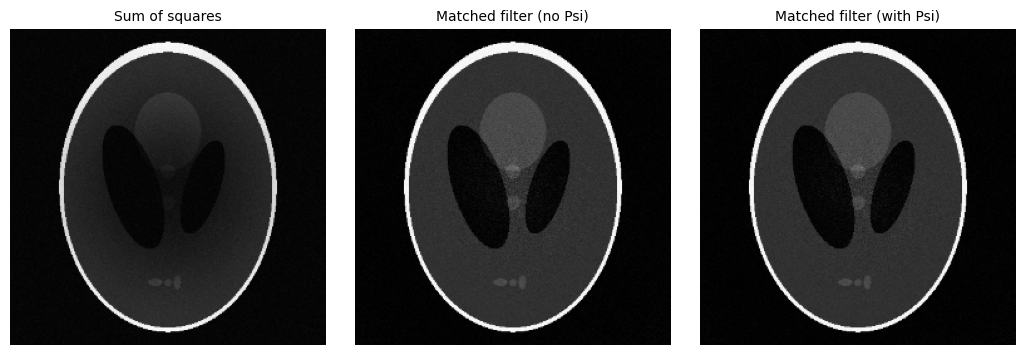

In [9]:
def coil_combine_sos(coil_images):
    return np.sqrt(np.sum(np.abs(coil_images)**2, axis=-1))

def coil_combine_matched(coil_images, sens, psi=None):
    Nc = coil_images.shape[-1]
    P = inv(psi) if psi is not None else np.eye(Nc)
    # f = (cH P c)^-1 (cH P m), evaluated at every pixel via einsum
    num = np.einsum('xyc,cd,xyd->xy', sens.conj(), P, coil_images)
    den = np.einsum('xyc,cd,xyd->xy', sens.conj(), P, sens)
    return num / (den + 1e-9)

imgs = ifft2c(d)
Psi  = estimate_psi(n)
sos      = coil_combine_sos(imgs)
mf_noPsi = coil_combine_matched(imgs, c, psi=None)
mf_Psi   = coil_combine_matched(imgs, c, psi=Psi)

show([sos, mf_noPsi, mf_Psi],
     ['Sum of squares', 'Matched filter (no Psi)', 'Matched filter (with Psi)'], size=3.5)


**Comment on the effect of $\boldsymbol\Psi$.** All three give a clean, uniform image
(unlike a naive complex sum, where out-of-phase coils would cancel — that's why SoS *squares*).
The matched filter is the SNR-optimal estimator; sum-of-squares approximates it with roughly a
**10% SNR penalty** and needs no sensitivities. Folding in the noise covariance down-weights coils
whose noise is correlated, so it counts each coil's *independent* information only once. With this
mildly-correlated array the visual change is subtle, but the noise statistics improve — and the
effect grows with stronger inter-coil coupling and at higher acceleration. We can quantify it:

In [10]:
# Quantify the effect: noise std measured in a signal-free corner of each combined image.
for label, im in [('SoS', sos), ('MF no Psi', mf_noPsi), ('MF with Psi', mf_Psi)]:
    print(f'{label:12s} background noise std = {np.abs(im)[:40, :40].std():.4e}')


SoS          background noise std = 7.9473e-03
MF no Psi    background noise std = 8.1533e-03
MF with Psi  background noise std = 7.5215e-03


### Solution 2 — Cartesian SENSE & g-factor

In [11]:
def sense_recon(kspace_full, sens, R, psi=None):
    N, FE, Nc = kspace_full.shape
    Nr = N // R
    P = inv(psi) if psi is not None else np.eye(Nc)
    aliased = ifft2c(kspace_full[::R])              # (Nr, FE, Nc) folded coil images
    recon = np.zeros((N, FE), dtype=complex)
    gmap  = np.zeros((N, FE))
    for yr in range(Nr):
        pos = (yr + np.arange(R) * Nr) % N          # R folded full-FOV rows
        C   = np.transpose(sens[pos], (1, 2, 0))    # (FE, Nc, R)
        I   = aliased[yr]                           # (FE, Nc)
        Ch  = np.conj(np.transpose(C, (0, 2, 1)))   # (FE, R, Nc)
        ChP = Ch @ P                                # (FE, R, Nc)
        M   = ChP @ C                               # (FE, R, R)  = C^H Psi^-1 C
        Minv = inv(M)
        u   = np.einsum('xrs,xs->xr', Minv @ ChP, I)        # (FE, R) unfolded pixels
        recon[pos] = u.T
        g   = np.sqrt(np.clip(np.real(np.einsum('xrr->xr', Minv)) *
                              np.real(np.einsum('xrr->xr', M)), 0, None))   # (FE, R)
        gmap[pos] = g.T
    return recon, gmap

def normalization(x):
    x = np.abs(x); return x / (x.max() + 1e-12)


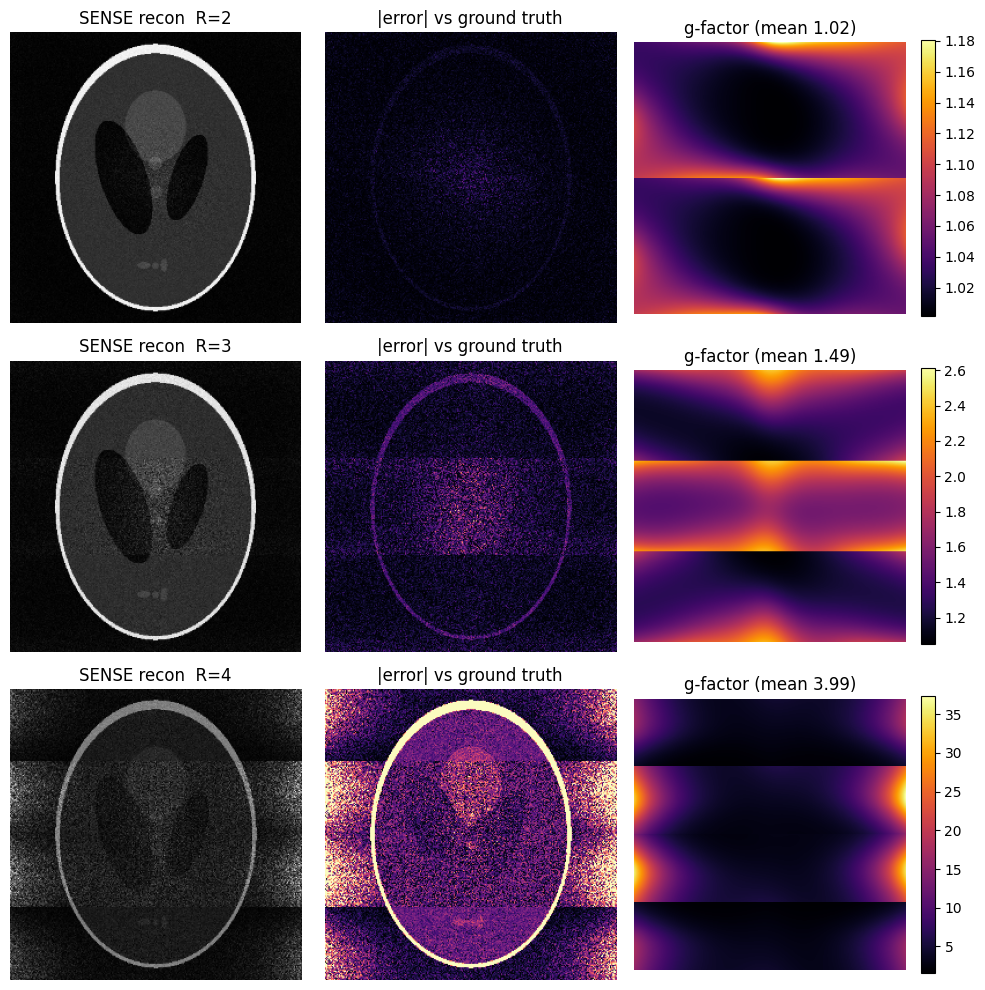

 R |  mean g |   max g |  PSNR(dB) |   SSIM
----------------------------------------------
 2 |   1.024 |    1.18 |     36.61 |  0.880
 3 |   1.490 |    2.43 |     28.45 |  0.630
 4 |   3.992 |   10.76 |     15.99 |  0.276


In [12]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

Psi = estimate_psi(n)
gt  = normalization(coil_combine_matched(ifft2c(d), c, psi=Psi))   # ground truth
mask = gt > 0.05

results = []
fig, ax = plt.subplots(3, 3, figsize=(10, 10))
for row, R in enumerate((2, 3, 4)):
    rec, g = sense_recon(d, c, R, psi=Psi)
    rec_n = normalization(rec)
    err   = np.abs(rec_n - gt)
    P = psnr(gt, rec_n, data_range=1.0)
    S = ssim(gt, rec_n, data_range=1.0)
    gbar = g[mask].mean()
    results.append((R, gbar, g[mask].max(), P, S))

    ax[row, 0].imshow(rec_n, cmap='gray');             ax[row, 0].set_title(f'SENSE recon  R={R}')
    ax[row, 1].imshow(err, cmap='magma', vmax=0.3);    ax[row, 1].set_title('|error| vs ground truth')
    im = ax[row, 2].imshow(g, cmap='inferno');         ax[row, 2].set_title(f'g-factor (mean {gbar:.2f})')
    fig.colorbar(im, ax=ax[row, 2], fraction=0.046)
    for a in ax[row]: a.axis('off')
plt.tight_layout(); plt.show()

print(f"{'R':>2} | {'mean g':>7} | {'max g':>7} | {'PSNR(dB)':>9} | {'SSIM':>6}")
print('-'*46)
for R, gm, gx, P, S in results:
    print(f"{R:>2} | {gm:>7.3f} | {gx:>7.2f} | {P:>9.2f} | {S:>6.3f}")


**Reading the results.** As $R$ increases the reconstruction degrades in a very specific way:
PSNR and SSIM fall, and the g-factor map lights up — **brightest in the center**, where every coil
overlaps and their sensitivity vectors are most alike, making $\mathbf C$ ill-conditioned. The mean
g-factor climbs steeply (≈1.0 at $R=2$, then up fast by $R=4$), which is exactly why clinical SENSE
rarely pushes 1D acceleration past 2–3 on an 8-channel array. The total SNR loss is
$g\sqrt R$: at $R=4$ you lose a factor $2$ just from $\sqrt R$, and the g-factor piles extra,
spatially-varying noise on top — that extra part is what better coils, regularization, or 2D
acceleration are designed to fight.

### Self-test — answers
1. **Readout undersampling saves nothing** because an entire readout line is collected in one shot
   during a single gradient echo; the time cost is dominated by the number of *phase-encode* steps
   (each needs its own TR). Fewer samples along readout ≠ fewer TRs.
2. **$R=5$ with 4 coils** makes $\mathbf C$ a $4\times5$ matrix — fewer equations than unknowns, so
   $\mathbf C^H\mathbf C$ is singular and the system is underdetermined. You need $N_c \ge R$.
3. **g-factor peaks at the center** because that's where all coils have appreciable, *similar*
   sensitivity. Similar columns in $\mathbf C$ → near-collinear → ill-conditioned inverse → large
   noise amplification. Toward the edges each pixel is dominated by one nearby coil, so the system
   is better conditioned.
4. **$R{=}2\to4$:** SNR scales as $1/(g\sqrt R)$. The $\sqrt R$ term alone worsens from $\sqrt2$ to
   $\sqrt4=2$. On top of that the **g-factor** grows (the "extra" loss from ill-conditioning), and it
   grows faster than linearly with $R$ — so the combined penalty more than doubles.

---
### 🔜 Where next
Cartesian SENSE works because aliasing is a clean, pixel-by-pixel fold. In **non-Cartesian**
acquisitions (radial, spiral) every pixel aliases with *all* others, the tidy $N_c\times R$ systems
disappear, and you must invert the full encoding operator **iteratively** — the subject of C06/C07,
alongside the k-space cousin of SENSE: **SMASH / GRAPPA**.